# **Colabユーザーへの注意**

# **このファイルに直接書き込まないでください—作業が消えることがあります！**

# **必ず作業前にコピーを作成してください。**

コピーの作り方

1. 左上の「File」をクリック  
> *「File」や「Runtime」などのメニューが見えないときは、右上の“v”マークを押して表示してください。*

2. 「Save a copy in Drive」を選ぶ  

3. コピーしたファイル名を「YOURNAMEs_FileName.ipynb」に変更する  
> 例：名前がOliviaなら → Olivias_FileName.ipynb  


---

* チェックマーク（✅）は保存されません。Chromeのリロードボタンでページを更新すると消えます。<br>  
途中で止めるときは、テキストセルを追加して「SO FAR DONE」など書いておいてください。

---

* Colabでは**30分〜90分ごとに以前の出力結果がリセットされます**。<br>  
そのため、`~~ is not defined`のようなエラーが**すごくよく起こります**。

🔁 `~~ is not defined`エラーが出たらどうする？

1. まず変数名のスペルを確認してください。<br>  
2. スペルが正しいのにまだエラーが出るなら、**そのセルをクリックして選択**してください。<br>  
3. 左上の「Runtime」→「Run before」をクリック。<br>  
→ これで**それまでのすべてのセルが再実行されます**。  
4. 再度、そのセルを実行してください。

もしこれでもエラーが直らなければ、<br>  
前のセルのTODOの答えに基本的なミスがあるかもしれません。<br>  
正しいかどうか確認してください。<br>  
またはChatGPTや他のコーディングアシスタントに助けを求めましょう。

### **Section 0: Preparation**

In [ ]:
# テンソルを見やすく表示する関数
import torch
import torch.nn as nn
import torch.nn.functional as F

def print_formatted_tensor(*args, width=6, decimals=2):
    """

    A function that neatly formats and displays a PyTorch Tensor, and also prints its size.

    Example usage:
        print_formatted_tensor("名前", tensor)
        print_formatted_tensor(tensor)

    Args:
        *args: If given 1 argument, it is treated as a tensor.
               If given 2 arguments, the first is treated as the name, the second as the tensor.
        width (int): Display width for each number (default: 6)
        decimals (int): Number of decimal places to show (default: 2)
    """


    # 引数からテンソルと名前を判定する
    if not args:
        raise ValueError("At least one argument is required.")
    if isinstance(args[0], str):
        if len(args) < 2:
            raise ValueError("Tensor is not specified.")
        name, tensor = args[0], args[1]
    else:
        name, tensor = None, args[0]

    # Tensorをリストに変換する
    tensor_list = tensor.detach().cpu().tolist()

    def format_list(lst, indent):
        """再帰的ネストリストの整形と文字列返却"""
        # 内容がリストなら再度返す
        if isinstance(lst, list) and lst and isinstance(lst[0], list):
            inner = ",\n".join(" " * indent + format_list(sub, indent + 2) for sub in lst)
            return "[\n" + inner + "\n" + " " * (indent - 2) + "]"
        # 番号付きリスト用
        return "[" + ", ".join(f"{v:{width}.{decimals}f}" for v in lst) + "]"

    # フォーマット済み文字列（最外枠の中括弧は除く）
    formatted = format_list(tensor_list, indent=9)
    inner_formatted = formatted[1:-1].strip()

    # 結果出力
    if name:
        print(name)
    print(f"Tensor Size: {list(tensor.size())}")
    print("tensor([")
    print(" " * 9 + inner_formatted)
    print(" " * 7 + "])")

# **Chapter 23: Relative Position Embedding(OverSimplified)**

### **Section 1: Attention の復習（読み物）**



まずは **Attention メカニズム** の復習をします。

このセクションを **20分以内に完全に理解できたら**、あなたの理解は完璧です。

逆に、**20分かけても全然ピンとこない、、、** だったら、復習が必要です！

AttentionHeadのChapterをもう一度、解き直してください。

なお、AttentionHeadのChapterの理解があやふやだと、

この後の章で結局は意味不明になり問題も解けなくなってしまいます。

もし20分かけても全然わからなかったら、面倒くさがらずに復習しましょう！

In [ ]:
import time
from IPython.display import clear_output

countdown = 1200
for i in range(countdown, 0, -1):
    clear_output(wait=True)
    print(f"⏳ Remaining : {i} seconds")
    time.sleep(1)
clear_output(wait=True)
print("💀 TIME UP! Please Reflect AttentionHead Chapter")

#### **Attention の復習**

`Token Embedding`と`Position Embedding`だけでは、各トークンは独立した埋め込み表現です。

このトークンごとの埋め込み表現を混ぜ合わせることで、文脈を埋め込んだ表現を得ることができます。

すなわちAttention機構とは`Context Embedding`です。

これを念頭に置いて復習していきましょう。

キーワードは「単語まぜまぜ」です。
まず、次の例文について考えましょう。

```
I love you
```

Attention の本質は、**各 query の視点から value の各要素を混ぜ合わせること**です。

<br>

---

<br>

#### **直感的な説明**

例えば、`query_you` の視点から、`value_I`, `value_love`, `value_you` を混ぜ合わせるとします。

直感的に考えると、`you` の視点から見れば、自分自身である `value_you` が最も重要です。

`love` は `you` に隣接していて位置的にも強い関係があり、意味的にも`you`は`love`の対象として強い関係を持ちます。

したがって、`value_I` の次に重要なのが `value_love`、最後に `value_I` でしょう。

<br>

※ 注：上記はあくまで解説のための例であり、実際の挙動とは異なる可能性があります。

<br>

---

<br>

#### **内積による関連度計算**

`query_you` と `key_love` の関連性は、ベクトル同士の内積で表現されます。

$$
\text{score}(you, love) = query_{you} \cdot key_{love}
$$

<br>

この内積が大きければ、`value_love` を多く混ぜます。

逆に内積が小さければ、混ぜる割合も小さくなります。

例えば、`query_you` と `key_love` の内積が、`query_you` と `key_I`の内積よりも大きかったとします。

つまり`you`にとって、`love`との関係の方が`I`との関係よりも重要だったとします。

この場合、`value_love` の混ぜる割合は、`value_I` の混ぜる割合よりも大きくなります。

このようにして、`key_i` との内積をもとに、`value_i`を混ぜる割合は決まります。

例えば、`query_you` の視点から、`value_I`, `value_love`, `value_you` を混ぜ合わせた文脈埋め込みベクトル`context_q_you`は次のように表されます。

<br>

$$
context_{q_{you}} = (q_{you} \cdot k_{I})  v_{I}
+ (q_{you} \cdot k_{love})  v_{love}
+ (q_{you} \cdot k_{you})  v_{you}
  \quad
$$

（※単純化のため、正規化およびマスクを考慮していません）

<br>

同じように `query_I` の視点からも：

$$
context_{q_{I}} = (q_{I} \cdot k_{I})  v_{I}
+ (q_{I} \cdot k_{love})  v_{love}
+ (q_{I} \cdot k_{you})  v_{you}
  \quad
$$

<br>

そして `query_love` の視点から：

$$
context_{q_{love}} = (q_{love} \cdot k_{I})  v_{I}
+ (q_{love} \cdot k_{love})  v_{love}
+ (q_{love} \cdot k_{you})  v_{you}
  \quad
$$

<br>

つまり、`query_I`, `query_love`, `query_you`のそれぞれの視点から`value_I`, `value_love`, `value_you` を混ぜ合わせて文脈埋め込みを行ったベクトル `context_query_I`, `context_query_love`,`context_query_you` は以下のように表現できます。

<br>

$$
\begin{bmatrix}
context_{q_{I}} \\
context_{q_{love}} \\
context_{q_{you}}
\end{bmatrix}
=
\begin{bmatrix}
(q_{I} \cdot k_{I})\, v_{I}
+ (q_{I} \cdot k_{\text{love}})\, v_{\text{love}}
+ (q_{I} \cdot k_{\text{you}})\, v_{\text{you}} \\
\\
(q_{\text{love}} \cdot k_{I})\, v_{I}
+ (q_{\text{love}} \cdot k_{\text{love}})\, v_{\text{love}}
+ (q_{\text{love}} \cdot k_{\text{you}})\, v_{\text{you}} \\
\\
(q_{\text{you}} \cdot k_{I})\, v_{I}
+ (q_{\text{you}} \cdot k_{\text{love}})\, v_{\text{love}}
+ (q_{\text{you}} \cdot k_{\text{you}})\, v_{\text{you}}
\end{bmatrix}
$$

<br>

これを（A）とします。これは全ての基本となる式です。

そしてこの式は、表形式と行列の形式の2パターンで表現されます。

<br>

---

（A）を表形式で表現してみましょう。

まず、queryとkeyの内積、すなわちAttetion Scoreを表で示します。

$$
\begin{array}{c|ccc}
\text{Query} \backslash \text{Key} & k_I & k_{\text{love}} & k_{\text{you}} \\
\hline
q_I & q_I \cdot k_I & q_I \cdot k_{\text{love}} & q_I \cdot k_{\text{you}} \\
q_{\text{love}} & q_{\text{love}} \cdot k_I & q_{\text{love}} \cdot k_{\text{love}} & q_{\text{love}} \cdot k_{\text{you}} \\
q_{\text{you}} & q_{\text{you}} \cdot k_I & q_{\text{you}} \cdot k_{\text{love}} & q_{\text{you}} \cdot k_{\text{you}}
\end{array}
$$

<br>

ここで、行方向のqueryはcontextに対応しており、列方向のkeyはvalueに対応していることを明示すれば、（A）を表現できます。

$$
\begin{array}{c|ccc}
\text{Context} & v_I & v_{\text{love}} & v_{\text{you}} \\
\hline
context_{q_I}
 & (q_I \cdot k_I)v_I +
 & (q_I \cdot k_{\text{love}})v_{\text{love}} +
 & (q_I \cdot k_{\text{you}})v_{\text{you}} \\
context_{q_{\text{love}}}
 & (q_{\text{love}} \cdot k_I)v_I +
 & (q_{\text{love}} \cdot k_{\text{love}})v_{\text{love}} +
 & (q_{\text{love}} \cdot k_{\text{you}})v_{\text{you}} \\
context_{q_{\text{you}}}
 & (q_{\text{you}} \cdot k_I)v_I +
 & (q_{\text{you}} \cdot k_{\text{love}})v_{\text{love}} +
 & (q_{\text{you}} \cdot k_{\text{you}})v_{\text{you}} \\
\end{array}
$$

<br>

---

次に、（A）を行列積の形式で表現します。

<br>

$$
\begin{aligned}
(QK^T)V
&=
\begin{bmatrix}
q_{I} \\
q_{love} \\
q_{you}
\end{bmatrix}
\begin{bmatrix}
k_{I} & k_{love} & k_{you}
\end{bmatrix}
\begin{bmatrix}
v_I \\
v_{love} \\
v_{you}
\end{bmatrix}
\\[6pt]
&=
\begin{bmatrix}
q_I \cdot k_I & q_I \cdot k_{love} & q_I \cdot k_{you} \\
q_{love} \cdot k_I & q_{love} \cdot k_{love} & q_{love} \cdot k_{you} \\
q_{you} \cdot k_I & q_{you} \cdot k_{love} & q_{you} \cdot k_{you}
\end{bmatrix}
\begin{bmatrix}
v_I \\
v_{love} \\
v_{you}
\end{bmatrix}
\\[6pt]
&=
\begin{bmatrix}
(q_{I} \cdot k_{I})\, v_{I}
+ (q_{I} \cdot k_{love})\, v_{love}
+ (q_{I} \cdot k_{you})\, v_{you} \\
\\
(q_{love} \cdot k_{I})\, v_{I}
+ (q_{love} \cdot k_{love})\, v_{love}
+ (q_{love} \cdot k_{you})\, v_{you} \\
\\
(q_{you} \cdot k_{I})\, v_{I}
+ (q_{you} \cdot k_{love})\, v_{love}
+ (q_{you} \cdot k_{you})\, v_{you}
\end{bmatrix}
\end{aligned}
$$




<br>

---

#### **未来の情報のマスク**

未来を参照することはできません。
例えば `query_love` の視点から `value_you` を混ぜようとしても、`you` は未来の単語なのでマスクされます。

<br>

表形式で示すと

$$
\begin{array}{c|ccc}
\text{Query} \backslash \text{Key} & k_I & k_{\text{love}} & k_{\text{you}} \\
\hline
q_I & q_I \cdot k_I & mask & mask \\
q_{\text{love}} & q_{\text{love}} \cdot k_I & q_{\text{love}} \cdot k_{\text{love}} & mask \\
q_{\text{you}} & q_{\text{you}} \cdot k_I & q_{\text{you}} \cdot k_{\text{love}} & q_{\text{you}} \cdot k_{\text{you}}
\end{array}
$$

<br>

$$
\begin{array}{c|ccc}
\text{Context} & v_I & v_{\text{love}} & v_{\text{you}} \\
\hline
context_{q_I}
 & (q_I \cdot k_I)v_I +
 & mask
 & mask \\
context_{q_{\text{love}}}
 & (q_{\text{love}} \cdot k_I)v_I +
 & (q_{\text{love}} \cdot k_{\text{love}})v_{\text{love}} +
 & mask \\
context_{q_{\text{you}}}
 & (q_{\text{you}} \cdot k_I)v_I +
 & (q_{\text{you}} \cdot k_{\text{love}})v_{\text{love}} +
 & (q_{\text{you}} \cdot k_{\text{you}})v_{\text{you}} \\
\end{array}
$$

<br>

---

<br>

行列の形式で示すと

$$
\begin{aligned}
(QK^T)V
&=
\begin{bmatrix}
q_{I} \\
q_{\text{love}} \\
q_{\text{you}}
\end{bmatrix}
\begin{bmatrix}
k_{I} & k_{\text{love}} & k_{\text{you}}
\end{bmatrix}
\begin{bmatrix}
v_I \\
v_{\text{love}} \\
v_{\text{you}}
\end{bmatrix}
\\[6pt]
&=
\begin{bmatrix}
q_I \cdot k_I & \text{mask} & \text{mask} \\
q_{\text{love}} \cdot k_I & q_{\text{love}} \cdot k_{\text{love}} & \text{mask} \\
q_{\text{you}} \cdot k_I & q_{\text{you}} \cdot k_{\text{love}} & q_{\text{you}} \cdot k_{\text{you}}
\end{bmatrix}
\begin{bmatrix}
v_I \\
v_{\text{love}} \\
v_{\text{you}}
\end{bmatrix}
\\[6pt]
&=
\begin{bmatrix}
(q_{I} \cdot k_{I})\, v_{I}
+ \text{mask}
+ \text{mask} \\
\\
(q_{\text{love}} \cdot k_{I})\, v_{I}
+ (q_{\text{love}} \cdot k_{\text{love}})\, v_{\text{love}}
+ \text{mask} \\
\\
(q_{\text{you}} \cdot k_{I})\, v_{I}
+ (q_{\text{you}} \cdot k_{\text{love}})\, v_{\text{love}}
+ (q_{\text{you}} \cdot k_{\text{you}})\, v_{\text{you}}
\end{bmatrix}
\end{aligned}
$$

<br>

---


#### **分散の考慮**

query や key の埋め込み次元数が増えると、Attention Scoreの分散も大きくなります。

そのため、スコアを埋め込み次元数 ( d ) の平方根で除算します。

$$
{AttentionScore}(Q, K) = \frac{QK^{T}}{\sqrt{d_{k}}} + {mask}
$$

#### **正規化**

Value を混ぜるときは、**重みの総和が 1** になる必要があります。

そのため、$QK^T$ によって得られた Attention Score（マスク適用後）を Softmax などで正規化し、

各スコアを「混ぜる割合」として利用します。

また、最後にDropoutを適用します。

<br>

$$
{AttentionWeights}(Q, K)
\;=\;
{Dropout}\Bigl(
  {Softmax}\Bigl(
    \frac{QK^{T}}{\sqrt{d_{k}}}
    \;+\;
    {mask}
  \Bigr)
\Bigr)
$$

<br>

この割合に基づき Value を加重平均することで、**文脈表現（Context Embedding: ベクトルまたは行列）** が得られます。

<br>

$$
{AttentionOutput}(Q, K, V)
\;=\;
{Dropout}\Bigl(
  {Softmax}\Bigl(
    \frac{QK^{T}}{\sqrt{d_{k}}}
    \;+\;
    {mask}
  \Bigr)
\Bigr)\;V
$$

<br>

---

復習終わり！

⌛️ タイマーを確認しよう

**Section 1: Attention の復習（読み物）** <label><input type="checkbox"> Mark as Done</label>

### **Section 2: Relative Position Embedding（読み物）**

#### AttentionScore 行列を見てみよう

次の文を考えます。

```
Hey my Honey I love you
```

ロマンチックな文章が出てきました。

AttentionScore 行列（Causal Mask 適用後）を見ていきましょう。

※ 単純化のため、次元数の平方根による除算は省略しています。

<br>

$$ \begin{array}{c|cccccc} \text{Query} \backslash \text{Key} & k_{Hey} & k_{my} & k_{Honey} & k_{I} & k_{love} & k_{you} \\ \hline q_{Hey} & q_{Hey} \cdot k_{Hey} & mask & mask & mask & mask & mask \\ q_{my} & q_{my} \cdot k_{Hey} & q_{my} \cdot k_{my} & mask & mask & mask & mask \\ q_{Honey} & q_{Honey} \cdot k_{Hey} & q_{Honey} \cdot k_{my} & q_{Honey} \cdot k_{Honey} & mask & mask & mask \\ q_{I} & q_{I} \cdot k_{Hey} & q_{I} \cdot k_{my} & q_{I} \cdot k_{Honey} & q_{I} \cdot k_{I} & mask & mask \\ q_{love} & q_{love} \cdot k_{Hey} & q_{love} \cdot k_{my} & q_{love} \cdot k_{Honey} & q_{love} \cdot k_{I} & q_{love} \cdot k_{love} & mask \\ q_{you} & q_{you} \cdot k_{Hey} & q_{you} \cdot k_{my} & q_{you} \cdot k_{Honey} & q_{you} \cdot k_{I} & q_{you} \cdot k_{love} & q_{you} \cdot k_{you} \end{array} $$


<br>

こちらの表もとってもロマンチック

いつ見ても美しい表ですね 😘 大好きだよ

---

#### 「I love you」との違いはある？

ここで少し考えてみましょう。

`I love you` のときの `you` にとっての `love` の関連性と、
`Hey my Honey I love you` のときの `you` にとっての `love` の関連性に違いはあるでしょうか？

「どっちも同じでしょ 🤔」と思いますよね。その通りです。

単語数が増えれば、全体の中での相対的なスコアは下がります。

ただ、それは Softmax 正規化で考慮されています。

$QK^T$ の計算そのものには関係ありません。

つまり、`I love you` の $q_{you} \cdot k_{love}$ と、
`Hey my Honey I love you` の $q_{you} \cdot k_{love}$ は、
やはり **同じ値になりそう**というのが直感的です。

---

#### 位置情報が影響する理由

実は、これらの値は本当は同じになって欲しいのですが、
実際には完全に同じにはなりません。

理由は 現在の Position Embedding の実装が絶対的位置情報に基づいているからです。

たとえば：

* `I love you` のとき

  * `you` の位置番号は 2
  * `love` の位置番号は 1

* `Hey my Honey I love you` のとき

  * `you` の位置番号は 5
  * `love` の位置番号は 4

AttentionScore の計算の前に、各トークンは
**Token Embedding** と **Position Embedding** を足し合わせて表現されます。

つまり、同じ単語でも位置番号が違えば、最終的な埋め込みベクトルも異なります。

例えば、

* 位置番号 2 の `you` と、位置番号 5 の `you` は別のベクトル。
* 位置番号 1 の `love` と、位置番号 4 の `love` も別のベクトル。

です。

<br>

そのため、
* 位置番号 2 の `you` から作られる $q_{you}$ と、位置番号 5 の `you` から作られる $q_{you}$ も異なる。

* 位置番号 1 の `love` から作られる $k_{love}$ と、 位置番号 4 の `love`から作られる$k_{love}$ も異なる。

結果として、

位置番号 2 の `you` から作られる $q_{you}$ と <br>
位置番号 1 の `love` から作られる $k_{love}$ の内積は、<br>

位置番号 5 の `you` から作られる $q_{you}$ と <br>
位置番号 4 の  `love` から作られる $k_{love}$ の内積と異なります。<br>

<br>

結果として、
`I love you` の $q_{you} \cdot k_{love}$ と、
`Hey my Honey I love you` の $q_{you} \cdot k_{love}$ も異なる可能性があります。

なお、${W_Q}$と${W_K}$を学習した結果、この2つの内積がほぼ同じになる可能性はあります。

しかし、学習をする前から等しくあってほしい！

というのが本音ですね。

---

#### 本当に必要なのは「相対的な距離」

繰り返しになりますが、Attention が本質的に知りたいのは **どのくらい離れているか**という相対的な位置関係です。

例を挙げると：

* `I love you` の場合：
  `you`（位置 2）と `love`（位置 1）の距離は 1。

* `Hey my Honey I love you` の場合：
  `you`（位置 5）と `love`（位置 4）の距離も 1。

つまり、相対的な距離は同じ。
このとき、両者の関連性が等しいほうが自然です。

---

#### 絶対位置は不要、相対位置で十分

もちろん、位置情報がまったく不要というわけではありません。

たとえば：

```
I love sushi 🍣 Especially salmon and tuna . how about you ?
```

この文では、
`you`（位置 11）と `love`（位置 1）は 10 も離れており、
関連性が低いのは明らかです。

しかしここでも重要なのは「どのくらい離れているか」という**距離情報**です。

つまり、やはり必要なのは **絶対位置** ではなく **相対位置** です。

---

## まとめ

* 絶対的な位置番号（例：2番目、5番目）は不要。
* 必要なのは、query と key が **どれだけ離れているか**という相対的な位置関係。

したがって、
従来の絶対位置に基づく Position Embedding は役目を終えます。

それでは別れの挨拶をしましょう😭

従来の`PositionEmbedding`全体を`"""`で囲み、ただの文字列として扱うことで、無効化します。

In [ ]:
# """script""" works as commentout, interpreting script as string

""" DELETE
class PositionEmbedding(nn.Module):
    def __init__(self, input_sequence_length = 8, embedding_dim = 8):
        super().__init__()
        # 位置埋め込み層
        self.position_embedding_layer = nn.Embedding(input_sequence_length, embedding_dim)

    def forward(self, input_indices):
        # 入力テンソル input_indices の形状：[バッチサイズ、シーケンス長]。
        sequence_length = input_indices.shape[1]

        # シーケンス長に応じた位置インデックスを作成する（例：[0, 1, 2, ..., sequence_length-1]）
        position_indices = torch.arange(sequence_length, device=input_indices.device)

        # 位置インデックスの埋め込みベクトルを取得する
        position_embeddings = self.position_embedding_layer.forward(position_indices)

        return position_embeddings
"""

`Position Embedding`クラスがなくなったので、`TokenEmbedding`クラスの埋め込みと`PositionEmbedding`クラスの埋め込みを足し合わせる`EmbeddingModule`クラスも今となっては不要です。

さようなら、今までありがとう😭

In [ ]:
# """script""" works as commentout, interpreting script as string

""" DELETE
class EmbeddingModule(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        # 各トークンの埋め込み層
        self.token_embedding_layer = TokenEmbedding(vocab_size = vocab_size, embedding_dim = config.embedding_dim)  # 単語埋め込み層
        self.position_embedding_layer = PositionEmbedding(input_sequence_length = config.input_sequence_length, embedding_dim = config.embedding_dim)  # 位置情報を埋め込む

    def forward(self, input_indices):
        # トークン埋め込みを取得
        token_embeddings = self.token_embedding_layer.embed(input_indices)

        # 位置埋め込みを取得する
        position_embeddings = self.position_embedding_layer.forward(input_indices)

        # トークン埋め込みと位置埋め込みを追加する
        embeddings = position_embeddings + token_embeddings
        return embeddings
"""

#### 相対位置を用いた内積の補正

私たちの狙いは、  
**i 番目のトークン由来の `query_i`** と **j 番目のトークン由来の `key_j`** の内積 $q_i \cdot k_j$ に、

**相対位置 $(i - j)$** に応じた補正項を組み込むことです。

1分だけ自分で考えてみましょう👍






In [ ]:
import time
from IPython.display import clear_output

countdown = 60
for i in range(countdown, 0, -1):
    clear_output(wait=True)
    print(f"⏳ Remaining : {i} seconds")
    time.sleep(1)
clear_output(wait=True)
print("TIME UP!")

まずは、とてもシンプルな案を考えます。

i 番目のトークン由来のクエリベクトルを $query_i$ , j番目のトークン由来のキーベクトルを $key_j$ とします。

$$
score_{ij} = query_i \cdot key_j + \left(\frac{1}{2}\right)^{(i - j)}
$$

この式では、  
相対位置が 1 つ離れるごとに補正値が半分になります。  
つまり、**相対位置が大きくなるほど関連度が指数的に減衰**します。


以下では、補正項を組み込んだ Attention Score を表で示します。  
（※簡略化のため、埋め込み次元数によるスケーリングは省略）

<br>

#### ① `I love you`

$$
\begin{array}{c|ccc}
Query/Key & k_I & k_{love} & k_{you} \\
\hline
q_I & q_I \cdot k_I + 1.0 & mask & mask \\
q_{love} & q_{love} \cdot k_I + 0.5 & q_{love} \cdot k_{love} + 1.0 & mask \\
q_{you} & q_{you} \cdot k_I + 0.25 & q_{you} \cdot k_{love} + 0.5 & q_{you} \cdot k_{you} + 1.0
\end{array}
$$

<br>

#### ② `Hey my Honey I love you`

$$
\scriptsize
\begin{array}{c|cccccc}
\text{Query/Key} & k_{Hey} & k_{my} & k_{Honey} & k_{I} & k_{love} & k_{you} \\
\hline
q_{Hey} & q_{Hey}\cdot k_{Hey}+1 & {mask} & {mask} & {mask} & {mask} & {mask} \\
q_{my} & q_{my}\cdot k_{Hey}+0.5 & q_{my}\cdot k_{my}+1 & {mask} & {mask} & {mask} & {mask} \\
q_{Honey} & q_{Honey}\cdot k_{Hey}+0.25 & q_{Honey}\cdot k_{my}+0.5 & q_{Honey}\cdot k_{Honey}+1 & {mask} & {mask} & {mask} \\
q_{I} & q_{I}\cdot k_{Hey}+0.125 & q_{I}\cdot k_{my}+0.25 & q_{I}\cdot k_{Honey}+0.5 & q_{I}\cdot k_{I}+1 & {mask} & {mask} \\
q_{love} & q_{love}\cdot k_{Hey}+0.0625 & q_{love}\cdot k_{my}+0.125 & q_{love}\cdot k_{Honey}+0.25 & q_{love}\cdot k_{I}+0.5 & q_{love}\cdot k_{love}+1 & {mask} \\
q_{you} & q_{you}\cdot k_{Hey}+0.03125 & q_{you}\cdot k_{my}+0.0625 & q_{you}\cdot k_{Honey}+0.125 & q_{you}\cdot k_{I}+0.25 & q_{you}\cdot k_{love}+0.5 & q_{you}\cdot k_{you}+1
\end{array}
$$


<br>

上記の 2 つのテーブルを見比べてみましょう。

例えば、$q_{you} \cdot k_{love}$ には、どちらの文でも同じ **+0.5** の補正が加えられています。

ここで注目すべきは、**絶対的位置埋め込み（Position Embedding）が存在しない** という点です。

そのため、`I love you` の $q_{you}$ と `Hey my Honey I love you` の $q_{you}$ は **完全に同一** です。

詳しい理由としては

- トークン埋め込みはどちらも “you” に対応しており同じ。
- `nn.LayerNorm` はトークンごとに適用されるため、これも同じ結果になります。
- 線形変換層 $W_q$ も共通です。

<br>

同様にして、`I love you` の $q_{love}$ と `Hey my Honey I love you` の $q_{love}$ も **完全に同一** です。

<br>

まとめると、$q_{you}$ も $k_{love}$ も両文で等しく、  
さらに相対位置 $(i - j)$ に基づく補正項も同じため、  
**内積スコアも完全に一致** します。

この補正項は内積 $q_{i} \cdot k_{j}$ に単純に加算されます。  
そこで、相対位置バイアス（`relative position bias`）と呼ぶことにします。

**Section 2: Relative Position Embedding（読み物）** <label><input type="checkbox"> Mark as Done</label>

### **Section 3: Relative Position Embedding (OverSimplified)**

$$
score_{ij} = query_i \cdot key_j + \left(\frac{1}{2}\right)^{(i - j)}
$$


上記のとってもシンプルなアイデア、果たしてうまくいくんでしょうか？

肝心の 1/2 という数字は、もちろん私たちが特に根拠なく設定したハイパーパラメータです。

1/3 の方がいいかもしれません。1/4 の方がいいかもしれません。

何がいいかなんてわからないので、とりあえず 1/2 でやりましょう。

<br>

頭の中で時間をかけて考えることも大事です。

しかし、コードを書いて、とにかく早く試すことが時に近道なこともあります。

上記のとてもシンプルなアイデアを実装していきましょう。

<br>

`I love you` に対応する擬似データを使って、
バッチサイズ1・トークン数3・埋め込み次元4 の例を実装します。

手順は以下の通りです：

1. **通常の Attention Score テーブル**を作る
2. **相対位置バイアス**のテーブルを作る
3. **両者を加算**してスコアを補正
4. **マスク処理**を適用する


バッチサイズは1、トークン長さは3、埋め込み次元数は4として、Query, Key, Value テンソルの擬似データを作成します。

In [ ]:
import torch
torch.manual_seed(123)

# 形状 (B=1, T=3, C=4) のランダムテンソルを作成
Query = torch.randn(1, 3, 4)
print_formatted_tensor("Query", Query)

Key = torch.randn(1, 3, 4)
print_formatted_tensor("Key", Key)

Value = torch.randn(1, 3, 4)
print_formatted_tensor("Value", Value)

#### 1. Attention Scoreのテーブルを作成する

まずは、Attention Scoreのテーブルを作成します。

これまでと全く同じです。まだマスクはされていません。

<br>

A. 表形式での表示

$$
\frac{1}{\sqrt{d_k}}
\left[
\begin{array}{c|ccc}
Query/Key & k_I & k_{love} & k_{you} \\
\hline
q_I & q_I \cdot k_I & q_I \cdot k_{love} & q_I \cdot k_{you} \\
q_{love} & q_{love} \cdot k_I & q_{love} \cdot k_{love} & q_{love} \cdot k_{you} \\
q_{you} & q_{you} \cdot k_I & q_{you} \cdot k_{love} & q_{you} \cdot k_{you}
\end{array}
\right]
$$

<br>

B. 行列計算での表示

$$
\begin{aligned}
\frac{1}{\sqrt{d_k}}(QK^T)
&=
\frac{1}{\sqrt{d_k}}
\begin{bmatrix}
q_{I} \\
q_{love} \\
q_{you}
\end{bmatrix}
\begin{bmatrix}
k_{I} & k_{love} & k_{you}
\end{bmatrix}
\\[6pt]
&=
\frac{1}{\sqrt{d_k}}
\begin{bmatrix}
q_I \cdot k_I & q_I \cdot k_{love} & q_I \cdot k_{you} \\
q_{love} \cdot k_I & q_{love} \cdot k_{love} & q_{love} \cdot k_{you} \\
q_{you} \cdot k_I & q_{you} \cdot k_{love} & q_{you} \cdot k_{you}
\end{bmatrix}
\end{aligned}
$$


In [ ]:
# 埋め込み次元数
embedding_dim = 4

# Attentionスコアを計算中 (QK^T) / sqrt(embedding_dim)
attention_weights_before_mask = # TODO: THINK_BY_YOURSELF
print_formatted_tensor("attention_weights_before_mask", attention_weights_before_mask)

**`Check Point`**
<label><input type="checkbox">↓以下と答えが一致したらチェックをつける</label>

```
attention_weights_before_mask
Tensor Size: [1, 3, 3]
tensor([
         [
           [ -0.16,   0.09,   0.27],
           [ -0.61,   0.32,   0.69],
           [ -0.15,   0.08,   0.05]
         ]
       ])
```

#### 2. 相対位置バイアスのテーブルを作る

表形式での表示

まずは、i番目のトークン由来の$q_{i}$からの、j番目のトークン由来の$k_{i}$ の相対位置`i-j`のテーブルを作成します。

$$
\begin{array}{c|ccc}
Query/Key & k_I & k_{love} & k_{you} \\
\hline
q_I & 0 & -1 & -2 \\
q_{love} & 1 & 0 & -1 \\
q_{you} & 2 & 1 & 0
\end{array}
$$

<br>

次に、先ほどの相対位置`i - j`のテーブルを用いて、
$\left(\tfrac{1}{2}\right)^{(i - j)}$ を適用した相対位置バイアスのテーブルを作成します。

$$
\begin{array}{c|ccc}
Query/Key & k_I & k_{love} & k_{you} \\
\hline
q_I & \left(\tfrac{1}{2}\right)^{0} = 1 &
\left(\tfrac{1}{2}\right)^{-1} = 2 &
\left(\tfrac{1}{2}\right)^{-2} = 4 \\
q_{love} & \left(\tfrac{1}{2}\right)^{1} = \tfrac{1}{2} &
\left(\tfrac{1}{2}\right)^{0} = 1 &
\left(\tfrac{1}{2}\right)^{-1} = 2 \\
q_{you} & \left(\tfrac{1}{2}\right)^{2} = \tfrac{1}{4} &
\left(\tfrac{1}{2}\right)^{1} = \tfrac{1}{2} &
\left(\tfrac{1}{2}\right)^{0} = 1
\end{array}
$$

この表は、各クエリ位置 `i` とキー位置 `j` の相対位置に基づいて
計算された相対位置バイアスを表しています。

なお、右上の半分については、あとでマスクされるので気にしないでください。



<br>

<br>

上記のテーブルは以下のような操作で作成されます。

列ベクトル から 行ベクトル を引くと、テンソルが出てきます。

$$
\begin{aligned}
\text{query_positions} &=
\begin{bmatrix}
0 \\
1 \\
2
\end{bmatrix},
\quad
\text{key_positions} =
\begin{bmatrix}
0 & 1 & 2
\end{bmatrix}
\end{aligned}
$$


$$
\begin{align}
\text{query_positions} - \text{key_positions}
&=
\begin{bmatrix}
0 \\
1 \\
2
\end{bmatrix}
-
\begin{bmatrix}
0 & 1 & 2
\end{bmatrix}
\\
&=
\begin{bmatrix}
0-0 & 0-1 & 0-2 \\
1-0 & 1-1 & 1-2 \\
2-0 & 2-1 & 2-2
\end{bmatrix}
\\
&=
\begin{bmatrix}
0 & -1 & -2 \\
1 & 0 & -1 \\
2 & 1 & 0
\end{bmatrix}
\end{align}
$$

このようにして、相対位置`i-j`テーブルが得られます。

次に、相対位置バイアスのテーブルを作成します。

数式としては違和感を感じるかもしれませんが、以下のように計算できます。

<br>

$$
\begin{aligned}
\text{relative_position_bias}
&= \left(\tfrac{1}{2}\right)^{\text{query_positions - key_positions}}
\\
&= \left(\tfrac{1}{2}\right)^{
\begin{bmatrix}
0 & -1 & -2 \\
1 & 0 & -1 \\
2 & 1 & 0
\end{bmatrix}
}
\\
&=
\begin{bmatrix}
\left(\tfrac{1}{2}\right)^0 & \left(\tfrac{1}{2}\right)^{-1} & \left(\tfrac{1}{2}\right)^{-2} \\
\left(\tfrac{1}{2}\right)^1 & \left(\tfrac{1}{2}\right)^0 & \left(\tfrac{1}{2}\right)^{-1} \\
\left(\tfrac{1}{2}\right)^2 & \left(\tfrac{1}{2}\right)^1 & \left(\tfrac{1}{2}\right)^0
\end{bmatrix}
\\
&=
\begin{bmatrix}
1 & 2 & 4 \\
\tfrac{1}{2} & 1 & 2 \\
\tfrac{1}{4} & \tfrac{1}{2} & 1
\end{bmatrix}
\end{aligned}
$$

<br>

お勉強はここまで。

設計図が頭に入ったら、コードという鋼鉄で、アイデアを実現する橋をかけましょう。

In [ ]:
current_query_len = Query.size(1)
current_key_len = Key.size(1)
print("current_query_len", current_query_len)
print("current_key_len", current_key_len)

$$
\begin{aligned}
\text{query_positions} &=
\begin{bmatrix}
0 \\
1 \\
2
\end{bmatrix},
\quad
\text{key_positions} =
\begin{bmatrix}
0 & 1 & 2
\end{bmatrix}
\end{aligned}
$$

In [ ]:
query_positions = # TODO: (query_len, 1)
print_formatted_tensor("query_positions", query_positions)

In [ ]:
key_positions = # TODO: (1, key_len)
print_formatted_tensor("key_positions", key_positions)

$$
\begin{align}
\text{relative_position_matrix}
&=
\text{query_positions} - \text{key_positions}
\\
&=
\begin{bmatrix}
0 \\
1 \\
2
\end{bmatrix}
-
\begin{bmatrix}
0 & 1 & 2
\end{bmatrix}
\\
&=
\begin{bmatrix}
0-0 & 0-1 & 0-2 \\
1-0 & 1-1 & 1-2 \\
2-0 & 2-1 & 2-2
\end{bmatrix}
\\
&=
\begin{bmatrix}
0 & -1 & -2 \\
1 & 0 & -1 \\
2 & 1 & 0
\end{bmatrix}
\end{align}
$$


In [ ]:
relative_position_matrix = # TODO: THINK_BY_YOURSELF. ヒント: とてもシンプル
print_formatted_tensor("relative_position_matrixx", relative_position_matrix)

$$
\begin{aligned}
\text{relative_position_bias}
&= \left(\tfrac{1}{2}\right)^{\text{relative_position_matrix}}
\\
&= \left(\tfrac{1}{2}\right)^{
\begin{bmatrix}
0 & -1 & -2 \\
1 & 0 & -1 \\
2 & 1 & 0
\end{bmatrix}
}
\\
&=
\begin{bmatrix}
\left(\tfrac{1}{2}\right)^0 & \left(\tfrac{1}{2}\right)^{-1} & \left(\tfrac{1}{2}\right)^{-2} \\
\left(\tfrac{1}{2}\right)^1 & \left(\tfrac{1}{2}\right)^0 & \left(\tfrac{1}{2}\right)^{-1} \\
\left(\tfrac{1}{2}\right)^2 & \left(\tfrac{1}{2}\right)^1 & \left(\tfrac{1}{2}\right)^0
\end{bmatrix}
\\
&=
\begin{bmatrix}
1 & 2 & 4 \\
\tfrac{1}{2} & 1 & 2 \\
\tfrac{1}{4} & \tfrac{1}{2} & 1
\end{bmatrix}
\end{aligned}
$$




In [ ]:
relative_position_bias_matrix = # TODO: THINK_BY_YOURSELF. ヒント: とてもシンプル
print_formatted_tensor("relative_position_bias_matrix", relative_position_bias_matrix)

このようにして、補正項の行列が計算できました。

負の距離をもつ要素が1より大きな値になります。

これらの要素にはいずれ`-inf`が足されて無効化されるので気にしないでください。

#### 3. 両者を加算してスコアを補正

$$
\begin{align}
\begin{bmatrix}
q_I \cdot k_I & q_I \cdot k_{love} & q_I \cdot k_{you} \\
q_{love} \cdot k_I & q_{love} \cdot k_{love} & q_{love} \cdot k_{you} \\
q_{you} \cdot k_I & q_{you} \cdot k_{love} & q_{you} \cdot k_{you}
\end{bmatrix}
+
\begin{bmatrix}
1 & 2 & 4 \\
\tfrac{1}{2} & 1 & 2 \\
\tfrac{1}{4} & \tfrac{1}{2} & 1
\end{bmatrix}
&=
\begin{bmatrix}
q_I \cdot k_I + 1 & q_I \cdot k_{love} + 2 & q_I \cdot k_{you} + 4 \\
q_{love} \cdot k_I + \tfrac{1}{2} & q_{love} \cdot k_{love} + 1 & q_{love} \cdot k_{you} + 2 \\
q_{you} \cdot k_I + \tfrac{1}{4} & q_{you} \cdot k_{love} + \tfrac{1}{2} & q_{you} \cdot k_{you} + 1
\end{bmatrix}
\end{align}
$$


In [ ]:
# attention_weights_before_mask に、相対位置に基づく補正項を加えて更新する
attention_weights_before_mask_biased = # TODO: THINK_BY_YOURSELF
print_formatted_tensor("attention_weights_before_mask_biased", attention_weights_before_mask_biased)

#### 4. マスク処理を適用する

従来の処理と全く同じです。

In [ ]:
T = 3
mask = # TODO: THINK_BY_YOURSELF. ヒント：AttentionHeadクラスでの実装を振り返る
print_formatted_tensor("mask", mask)

In [ ]:
masked_attention_weights = attention_weights_before_mask_biased.masked_fill(mask == 1, float('-inf')) # THINK_BY_YOURSELF. ヒント：AttentionHeadクAttentionHeadクラスでの実装を振り返る
print_formatted_tensor("masked_attention_weights", masked_attention_weights)

このようにして、相対位置に基づく補正が完了しました。

**Section 3: Relative Position Embedding (OverSimplified)** <label><input type="checkbox"> Mark as Done</label>

### **Section 4: `Relative Position Embedding` クラスの作成**

ここまでの処理をまとめて、`RelativePositionEmbedding`クラスを作成します。

`device`で`cpu`か`cuda`かを指定する処理が追加されています。

🔘 **Options**: 余計な選択肢があるかもしれません。同じ選択肢を2回以上使うかもしれません。

`torch`　`nn`　`F`　`math`　`arange`　`zeros`　`ones`　`query_len`　`key_len`　`query_positions`　`key_positions`　`relative_position_matrix`　`relative_position_bias_matrix`　`0.5`　`2.0`　`**`　`//`　`[:, None]`　`[None, :]`　`(Tq, Tk)`　`device`　`device_type`


In [ ]:
############ NEW ############
class RelativePositionEmbedding(nn.Module):
    # 相対位置 (i - j) に基づいて、固定の指数減衰補正を返す。
    # (例) +1 → 1.0, +2 → 0.5, +3 → 0.25 ...
    def __init__(self):
        super().__init__()

    def forward(self, query_len, key_len, device_type=None):
        # Query と Key の位置インデックスを作成
        query_positions = ______._______(__________, device=device_type)[:, None]  # (Tq, 1) # TODO: FILL
        key_positions   = ______._______(__________, device=___________)[None, :]  # (1, Tk) # TODO: FILL

        # 相対位置 (i - j)
        relative_position_matrix = ______________________ - ____________________  # (Tq, Tk) # TODO: FILL

        # (1/2)^(i-j)
        relative_position_bias_matrix = ____ __ ____________________________  # TODO: FILL

        # (Tq, Tk)
        return ________________________________ # TODO: FILL
############ NEW ############

<details>
<summary>クリックして答えを表示/非表示する</summary>

```python
class RelativePositionEmbedding(nn.Module):
    # 相対位置 (i - j) に基づいて、固定の指数減衰補正を返す。
    # (例) +1 → 1.0, +2 → 0.5, +3 → 0.25 ...
    def __init__(self):
        super().__init__()

    def forward(self, query_len, key_len, device_type=None):
        # Query と Key の位置インデックスを作成
        query_positions = torch.arange(query_len, device=device_type)[:, None]  # (Tq, 1)
        key_positions = torch.arange(key_len, device=device_type)[None, :]      # (1, Tk)

        # 相対位置 (i - j)
        relative_position_matrix = query_positions - key_positions  # (Tq, Tk)

        # (1/2)^(i-j)
        relative_position_bias_matrix = 0.5 ** relative_position_matrix

        # (Tq, Tk)
        return relative_position_bias_matrix
```

In [ ]:
relative_position_embedding_layer = RelativePositionEmbedding()

In [ ]:
# (B, T, C) -> T
current_query_len = Query.size(1)
print("current_query_len", current_query_len)

# (B, T, C) -> T
current_key_len = Key.size(1)
print("current_key_len", current_key_len)

`cuda`が使用可能であれば`cuda`が選択されます。最後に訓練を回すので、`cuda`であることを確認しましょう。

もし`cpu`であれば、ランタイムを`T4 GPU`にきりかえて、冒頭からタイマー以外のセルを実行しましょう。

In [ ]:
current_device_type = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("current_device_type", current_device_type)

**`Check Point`**
<label><input type="checkbox">`cuda`であることを確認した</label>

In [ ]:
relative_position_bias_matrix = relative_position_embedding_layer(
    query_len = current_query_len,
    key_len = current_key_len,
    device_type = current_device_type) # (T, T)
print_formatted_tensor("relative_position_bias_matrix", relative_position_bias_matrix)

さらに、`AttentionHead`クラスに`RelativePositionEmbedding`クラスを統合します。

🔘 **Options**: 余計な選択肢があるかもしれません。同じ選択肢を2回以上使うかもしれません。

`self.relative_position_embedding_layer`　`RelativePositionEmbedding`　`Query`　`Key`　`size`　`T`　`B`　`C`　`shape`　`relative_position_bias_matrix`　`self.dropout`　`self.key_fc`　`transpose`　`input_tensor`　`F.relu`　`F.softmax`


In [ ]:
class AttentionHead(nn.Module):
    def __init__(self, head_size, config):
        super().__init__()
        self.key_fc= nn.Linear(config.embedding_dim, head_size, bias=False)
        self.query_fc = nn.Linear(config.embedding_dim, head_size, bias=False)
        self.value_fc = nn.Linear(config.embedding_dim, head_size, bias=False)

        # ドロップアウト
        self.dropout = nn.Dropout(config.dropout_rate)
        self.head_size = head_size

        ############ NEW ############
        _______________________________ = _________________________________()  # TODO: FILL
        ############ NEW ############

    def forward(self, input_tensor):
        B, T, C = input_tensor.shape  # バッチ、トークン長、埋め込みチャネル

        Key = self.key_fc.forward(input_tensor)     # (B, T, head_size)
        Query = self.query_fc.forward(input_tensor)   # (B, T, head_size)
        Value = self.value_fc.forward(input_tensor)   # (B, T, head_size)

        # Attentionスコアを計算中 (QK^T) / sqrt(embedding_dim)
        attention_weights_before_mask = Query @ Key.transpose(-2, -1) * self.head_size**(-0.5)

        ############ NEW ############
        relative_position_bias_matrix = _____________________________________________(
            query_len = __,
            key_len = __,
            device_type=input_tensor.device)  # (T, T)
        attention_weights_before_mask = attention_weights_before_mask + _____________________________  # TODO: FILL
        ############ NEW ############

        # マスク適用済み
        mask = torch.triu(torch.ones(T, T), diagonal=1).to(input_tensor.device)
        masked_attention_weights = attention_weights_before_mask.masked_fill(mask == 1, float('-inf'))

        # ソフトマックス → ドロップアウト → 重み付き和
        attention_weights = F.softmax(masked_attention_weights, dim=-1)
        attention_weights = self.dropout(attention_weights)

        out = attention_weights @ Value  # (B, T, head_size)
        return out

<details>
<summary>クリックして答えを表示/非表示する</summary>

```python
class AttentionHead(nn.Module):
    def __init__(self, head_size, config):
        super().__init__()
        self.key_fc= nn.Linear(config.embedding_dim, head_size, bias=False)
        self.query_fc = nn.Linear(config.embedding_dim, head_size, bias=False)
        self.value_fc = nn.Linear(config.embedding_dim, head_size, bias=False)

        # ドロップアウト
        self.dropout = nn.Dropout(config.dropout_rate)
        self.head_size = head_size

        ############ NEW ############
        self.relative_position_embedding_layer = RelativePositionEmbedding()
        ############ NEW ############

    def forward(self, input_tensor):
        B, T, C = input_tensor.shape  # バッチ、トークン長、埋め込みチャネル

        Key = self.key_fc.forward(input_tensor)     # (B, T, head_size)
        Query = self.query_fc.forward(input_tensor)   # (B, T, head_size)
        Value = self.value_fc.forward(input_tensor)   # (B, T, head_size)

        # Attentionスコアを計算中 (QK^T) / sqrt(embedding_dim)
        attention_weights_before_mask = Query @ Key.transpose(-2, -1) * self.head_size**(-0.5)

        ############ NEW ############
        relative_position_bias_matrix = self.relative_position_embedding_layer(
            query_len = T,
            key_len = T,
            device_type=input_tensor.device)  # (T, T)
        attention_weights_before_mask = attention_weights_before_mask + relative_position_bias_matrix  # add bias
        ############ NEW ############

        # マスク適用済み
        mask = torch.triu(torch.ones(T, T), diagonal=1).to(input_tensor.device)
        masked_attention_weights = attention_weights_before_mask.masked_fill(mask == 1, float('-inf'))

        # ソフトマックス → ドロップアウト → 重み付き和
        attention_weights = F.softmax(masked_attention_weights, dim=-1)
        attention_weights = self.dropout(attention_weights)

        out = attention_weights @ Value  # (B, T, head_size)
        return out
```

**Section 4: `Relative Position Embedding` クラスの作成** <label><input type="checkbox"> Mark as Done</label>

### **Section 5: モデルクラス全体の作成**

データをダウンロードします。

In [ ]:
!wget https://huggingface.co/datasets/HayatoHongo/TinyStories_npy/resolve/main/TinyStories-train.npy

DataLoaderに変更はありません。

In [ ]:
import torch
import numpy as np
import tiktoken

class DataLoader:
    def __init__(self, npy_path, config):
        # 大きなトークン化済みファイル（.npy）をメモリマップで開き、
        # 必要な部分だけをランダムに読み出すデータローダー。
        self.config = config  # モデル設定（batch_size, seq_lenなど）

        self.encoder = tiktoken.get_encoding("gpt2")
        self.vocab_size = self.encoder.n_vocab

        # 巨大なトークン化済み .npy ファイルをメモリマップで開く
        self.data = np.load(npy_path, mmap_mode="r")

        # 訓練・検証用データの範囲を決める（実データは共有）
        self.train_data, self.val_data = self.split_data()

    def split_data(self):
        # データを 90%:10% に分割し、インデックス範囲で保持
        split_index = int(0.9 * len(self.data))
        return (0, split_index), (split_index, len(self.data))

    def get_batch(self, split):

        # 指定された split ('train' or 'val') からランダムにバッチを作る。
        # メモリに乗らない巨大ファイルから、必要部分だけをスライスして読み込む。

        # splitに応じたデータ範囲を取得
        range_start, range_end = (
            self.train_data if split == 'train' else self.val_data
        )

        # ランダムに開始位置を選ぶ
        start_indices = np.random.randint(
            range_start,
            range_end - self.config.input_sequence_length - 1,
            size=self.config.batch_size
        )

        # 各開始位置から連続したトークン列を取り出してバッチ化
        # Pytorchの`nn.Embedding`は torch.int64 しか受け付けない。
        # np.int64に変換した状態で torch.from_numpy を適用すると、torch.int64 に変換される。
        input_sequences = torch.stack([
            torch.from_numpy(
                self.data[start:start + self.config.input_sequence_length].astype(np.int64)
            )
            for start in start_indices
        ])

        # 1トークン先をターゲットにする
        # Pytorchの`nn.Embedding`はtorch.int64しか受け付けないため、np.int64に変換する必要がある。
        target_sequences = torch.stack([
            torch.from_numpy(
                self.data[start + 1:start + self.config.input_sequence_length + 1].astype(np.int64)
            )
            for start in start_indices
        ])

        # GPUなどのデバイスに転送
        return (
            input_sequences.to(self.config.device_type),
            target_sequences.to(self.config.device_type)
        )

`TokenEmbedding`クラスに変更はありません。

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        # 語彙数x埋め込み次元の埋め込みテーブルを定義する
        self.token_embedding_table = nn.Embedding(vocab_size, embedding_dim)

    def embed(self, input_indices):
        # 入力インデックスに対応する埋め込みベクトルを取得する
        return self.token_embedding_table.forward(input_indices)

`MultiHeadAttention`クラス、`FeedForward`クラス、`TransformerBlock`クラス、`VocabularyLogits`クラスも変更はありません。

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.num_attention_heads = config.num_attention_heads
        self.embedding_dim = config.embedding_dim
        self.head_size = int(self.embedding_dim / self.num_attention_heads)

        # ModuleListで複数のヘッドを管理する
        self.attention_heads = nn.ModuleList([
            AttentionHead(self.head_size, config)
            for _ in range(self.num_attention_heads)
        ])

        # 各ヘッドの出力を混合する線形層
        self.output_projection = nn.Linear(self.embedding_dim, self.embedding_dim)

        # 出力のドロップアウト
        self.dropout = nn.Dropout(config.dropout_rate)

    def forward(self, input_tensor):
        # 各ヘッドの出力を取得する
        # (B, T, head_size)のリスト
        head_outputs_list = [head.forward(input_tensor) for head in self.attention_heads]

        # 全てのヘッドの出力を連結 → (B, T, embedding_dim)
        concatenated = torch.cat(head_outputs_list, dim=-1)

        # 線形変換での出力混合
        projected = self.output_projection.forward(concatenated)

        # 最終出力にドロップアウトを適用する
        output = self.dropout.forward(projected)

        return output

class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.embedding_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.embedding_dim),
            nn.Dropout(config.dropout_rate),
        )

    def forward(self, input_tensor):
        return self.net(input_tensor)

class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()

        # 各LayerNormは独自のbetaとgammaを保持します。
        self.layer_norm1 = nn.LayerNorm(config.embedding_dim)
        self.layer_norm2 = nn.LayerNorm(config.embedding_dim)

        self.multihead_attention = MultiHeadAttention(config=config)
        self.feed_forward = FeedForward(config=config)

    def forward(self, input_tensor):
        # forwardメソッドは省略されています。
        normed_input = self.layer_norm1(input_tensor) # 入力にレイヤーノルムを適用する
        attention_output = self.multihead_attention(normed_input) # マルチヘッドアテンションを適用する
        residual_attention = attention_output + input_tensor # "before! layernorm1"を追加
        normed_attention = self.layer_norm2(residual_attention) # 残差出力に再度LayerNormを適用する
        feedforward_output = self.feed_forward(normed_attention) # フィードフォワードネットワークを適用する
        final_output = feedforward_output + residual_attention # "before" layernorm2 を追加する！

        return final_output

class VocabularyLogits(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        # レイヤー正規化
        self.output_norm = nn.LayerNorm(config.embedding_dim)
        # 語彙数の射影
        self.vocab_projection = nn.Linear(config.embedding_dim, vocab_size)

    def forward(self, transformer_block_output):
        # Transformerブロックの出力にLayer normalizationを適用する。
        normalized_output = self.output_norm.forward(transformer_block_output)  # (B, T, C)

        # 線形層でスコアを語彙数次元に変換する。
        vocab_logits = self.vocab_projection.forward(normalized_output)  # (B, T, V)

        return vocab_logits

`nanoGPT`クラスについても修正があります。

`EmbeddingModule`クラスのインスタンスを`TokenEmbedding`クラスのインスタンスに入れ替えます。

In [ ]:
class nanoGPT(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        self.config = config  # 生成時にも使うので保持してください。
        """ DELETE
        self.embedding = EmbeddingModule(vocab_size, config=config)
        """
        self.token_embedding_layer = TokenEmbedding(vocab_size = vocab_size, embedding_dim = config.embedding_dim)
        self.blocks = nn.Sequential(*[TransformerBlock(config=config) for _ in range(config.layer_count)])
        self.vocab_projection = VocabularyLogits(vocab_size=vocab_size, config=config)
        self.criterion = nn.CrossEntropyLoss()

    # 尤度と損失を計算する
    def forward(self, input_indices, target_indices):
        """ DELETE
        embeddings = self.embedding(input_indices)
        blocks_output = self.blocks(embeddings)
        """
        ########## NEW ##########
        token_embeddings = # TODO: THINK_BY_YOURSELF.
        blocks_output = self.blocks(token_embeddings)
        ########## NEW ##########

        logits = self.vocab_projection(blocks_output)

        # 推論時はターゲットがないため、lossはNoneです
        # —確率（ロジット）のみ返されます。
        if target_indices is None:
            return logits, None

        batch_size, token_len, vocab_size = logits.shape
        logits = logits.view(batch_size * token_len, vocab_size)
        targets = target_indices.view(batch_size * token_len)
        loss = self.criterion(logits, targets)

        return logits, loss

    # テキストを生成する
    def generate(self, input_indices, max_new_tokens):
        # 指定したトークン数max_new_tokensのみ生成する
        for _ in range(max_new_tokens):
            input_conditioned = input_indices[:, -self.config.input_sequence_length:] # 入力を切り取る

            # 順伝播は `(likelihood, loss)` を返す—`likelihood` のみを `logits` として保持する。
            logits, _ = self.forward(input_conditioned, target_indices=None)
            last_logits = logits[:, -1, :] # 最後のトークンのロジットを抽出する
            probs = F.softmax(last_logits, dim=-1) # Softmaxで尤度を確率に変換する

            # 次のトークンをサンプリングする
            next_token = torch.multinomial(probs, num_samples=1)

            # 新しいトークンを統合し、input_indicesを更新する。
            input_indices = torch.cat((input_indices, next_token), dim=1)

        # 最終的な`input_indices`を返す。長さは元の`input_indices`＋`max_new_tokens`
        return input_indices

`Trainer`クラスについてついては変更はありません。

In [ ]:
import time

class Trainer:
    def __init__(self, model, optimizer, data_loader, config):
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config

        self.steps = []
        self.train_losses = []
        self.val_losses = []
        self.tokens_per_second_list = []
        self.total_seen_tokens_list = []
        self.total_train_time_list = []


    def train_step(self):
        # トレーニング用バッチを取得。
        input_batch, target_batch = self.data_loader.get_batch('train')
        self.optimizer.zero_grad()

        # モデルの順伝播と損失計算
        logits, loss = self.model(input_batch, target_batch)
        loss.backward()  # 誤差逆伝播
        self.optimizer.step()  # パラメータ更新

        return loss.item() # 損失の値を返す

    def evaluate(self):
        self.model.eval()  # 評価モードに切り替え
        losses = {"train": [], "val": []} # 学習・検証データ両方の損失を計算
        with torch.no_grad():
            for split in ['train', 'val']:
                for _ in range(self.config.evaluation_loops):
                    input_batch, target_batch = self.data_loader.get_batch(split)
                    _, loss = self.model(input_batch, target_batch)
                    losses[split].append(loss.item())
        self.model.train()  # 再び学習モードへ戻す

        # 各データセット（train, val）での損失の平均を計算して返す
        return {split: sum(values) / len(values) for split, values in losses.items()}

    def train(self):
        # (configで指定された回数+1)だけtrain_stepを実行する。
        for step in range(self.config.total_training_steps+1):
            # 100回ごとに評価する。
            if step % self.config.evaluation_frequency == 0:
                if step == 0:
                  tokens_per_second = None
                  total_train_time = 0
                else:
                  current_eval_start_time = time.time()
                  evaluation_interval = current_eval_start_time - last_eval_end_time
                  total_train_time += evaluation_interval
                  tokens_per_evaluation_interval = self.config.batch_size * self.config.input_sequence_length * self.config.evaluation_frequency
                  tokens_per_second = tokens_per_evaluation_interval / evaluation_interval

                eval_loss = self.evaluate()
                total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step

                print(
                    f"step {step:05d} | "
                    f"train loss {eval_loss['train']:.4f} | "
                    f"val loss {eval_loss['val']:.4f} | "
                    f"tok/s {int(tokens_per_second) if tokens_per_second is not None else 'None'} | "
                    f"tokens {total_seen_tokens:,} | "
                    f"time {total_train_time:.2f}s"
                )

                self.steps.append(step)
                self.train_losses.append(eval_loss['train'])
                self.val_losses.append(eval_loss['val'])
                self.tokens_per_second_list.append(tokens_per_second)
                self.total_seen_tokens_list.append(total_seen_tokens)
                self.total_train_time_list.append(total_train_time)

                # この評価が終わった時間を記録する。次の評価開始時との時間差が`evaluation_interval`となる。
                last_eval_end_time = time.time()

            # 1回の学習ステップ（毎回行う主な処理）
            train_loss = self.train_step()

**Section 5: モデルクラス全体の作成** <label><input type="checkbox"> Mark as Done</label>

### **Section 6: 学習**

今回はそもそも、うまくいくか分からない実験です。

最初の1,000stepだけ確認しましょう。

およそ6分ほどかかります。

In [ ]:
# モデル設定を保存する設定クラス
class ModelConfig:
    batch_size = 16
    input_sequence_length = 512  # データロードにかかる時間の割合を下げるため、長めのシークエンスを一度に取り出す。
    ########## NEW ##########
    total_training_steps = 1_000  # おおよそ6分
    ########## NEW ##########
    device_type = 'cuda'  # 使用デバイスはGPUに固定する
    evaluation_frequency = 100  # モデル性能評価の頻度
    learning_rate = 2e-3  # 学習率
    evaluation_loops = 10  # 評価中の繰り返し回数
    embedding_dim = 256  # 埋め込み次元数
    hidden_dim = 1024
    num_attention_heads = 4  # アテンションヘッドの数
    layer_count = 4  # モデルの層数
    dropout_rate = 0.1  # ドロップアウト確率
    random_seed_value = 1337  # 再現性のための乱数シード

In [ ]:
# 設定を読み込みシードを設定する
config = ModelConfig()
torch.manual_seed(config.random_seed_value)  # 再現性確保のため乱数シードを設定

Dataloaderインスタンスを作成してください。


In [ ]:
data_loader = # TODO: クラス(インスタンス)

In [ ]:
# モデルとオプティマイザを初期化する
model = nanoGPT(vocab_size = data_loader.vocab_size, config = config).to(config.device_type)
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)

In [ ]:
# モデルのパラメータ数を表示する
print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### 🚀 学習スタート！

今回は **15 GB RAM の T4 GPU** を使用し、
`batch size = 16`、`total steps = 1,000` の設定で進めます。

今回は実験的検証なので、長い訓練は行いません。学習はおよそ6分で完了します。

従来の絶対的位置埋め込みで`TinyStories`を学習させたときのログを探してきてください。

ロスの下がり方を比較しましょう。

In [ ]:
print("===トレーニングが正常に開始されました===")

# モデルを学習する
trainer = Trainer(model, optimizer, data_loader, config)
trainer.train()

横軸を`Step`、縦軸を`Loss`として`matplotlib`を使って描画しましょう。

In [ ]:
# グラフ描画。
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(trainer.steps, trainer.train_losses, label='Train Loss')
plt.plot(trainer.steps, trainer.val_losses, label='Validation Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Steps')
plt.legend()
plt.grid(True)
plt.show()

学習ログはきちんと保管しましょう。

In [ ]:
# 学習済み trainer からログをまとめる
results = {
    "step": trainer.steps,
    "train_loss": trainer.train_losses,
    "val_loss": trainer.val_losses,
    "tokes_per_second": trainer.tokens_per_second_list,
    "total_seen_tokens": trainer.total_seen_tokens_list,
    "total_train_time": trainer.total_train_time_list,
}

print(results)

In [ ]:
import pandas as pd
# pandas の DataFrame に変換
df = pd.DataFrame(results)

In [ ]:
df

絶対的位置埋め込みの時の学習ログを読み込み、比較しましょう。

In [ ]:
df_previous = pd.read_csv("/content/drive/MyDrive/nanoGPT_logs/Chapter22/training_logs.csv")

In [ ]:
df_previous

In [ ]:
# step <= 1000 の範囲に絞る
df_relative = df[df.step <= 1000]
df_traditional = df_previous[df_previous.step <= 1000]

# プロット
plt.plot(
    df_relative.step,
    df_relative.val_loss,
    label="Relative (OverSimplified)"
)

plt.plot(
    df_traditional.step,
    df_traditional.val_loss,
    label="Traditional"
)

plt.legend()
plt.show()

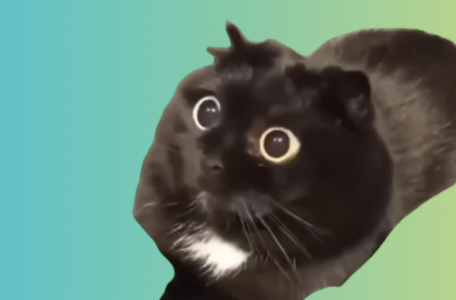

なんと、ほとんど差がありません！

思い出してください、相対位置埋め込みには、特に学習可能なパラメータはありませんでした。

あくまで、$+\left(\frac{1}{2}\right)^{(i - j)}$ の補正項だけです。

<br>

学習可能なパラメータを持たない相対位置埋め込みが、

大量の学習可能パラメータを持つ従来の絶対位置埋め込みと比べて、

初期学習の段階でほとんど遜色がない結果となりました。

<br>

この結果からも、相対位置埋め込みのポテンシャルが十分に感じられます。

今後は、この相対位置埋め込みをさらに改良していきます。

今回のログをGoogle Driveに保存しましょう。

In [ ]:
# 保存先のフォルダを作成する
import os
dir_path = "/content/drive/MyDrive/nanoGPT_logs/Chapter23/RPE(OverSimplified)"
os.makedirs(dir_path, exist_ok=True)

In [ ]:
# csvファイルとして保存する先のパスを指定する。
save_path = os.path.join(dir_path, "training_logs.csv")

In [ ]:
# CSVとして保存
df.to_csv(save_path, index=False)
print(f"✅ CSV saved to: {save_path}")

In [ ]:
# クラス属性を辞書化
config_class_dict = vars(config.__class__)
print(config_class_dict)

In [ ]:
# 辞書の (key, value) ペアを取得
config_dict_items = config_class_dict.items()
print(config_dict_items)

In [ ]:
config_dict = {
    key: value
    for key, value in config_dict_items
    if not key.startswith("__")
}

print(config_dict)

In [ ]:
# 保存先のファイルパスを作成する。
config_path = os.path.join(dir_path, "model_config.json")
print(config_path)

In [ ]:
import json
# ファイルを「書き込みモード(w)」で開き、変数`f`で操作できるようにする
with open(config_path, "w") as f:
    json.dump(config_dict, f)

print(f"✅ Config saved to: {config_path}")

In [ ]:
model_path = os.path.join(dir_path, "model.pt")
print(model_path)

In [ ]:
torch.save(model.state_dict(), model_path)
print(f"✅ Model saved to: {model_path}")

**Section 6: 学習** <label><input type="checkbox"> Mark as Done</label>

**⚠️ 右上の 🔽 からランタイムを接続解除してクレジット消費を止めてください。** <label><input type="checkbox">接続解除した</label>

**Chapter 23: Relative Position Embedding(OverSimplified)** <label><input type="checkbox"> Mark as Done</label>